In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import BertModel, BertTokenizer

#

In [2]:
# Create tokenizer and instantiate the model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

#

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [6]:
emb = model.embeddings.word_embeddings.weight

In [53]:
sentence = "My phone is in the kitchen near the cold ice cream"

token_ids = tokenizer.encode(sentence, return_tensors='pt')[0][1:-1]

word_tokens = tokenizer.decode(token_ids).split()

['my',
 'phone',
 'is',
 'in',
 'the',
 'kitchen',
 'near',
 'the',
 'cold',
 'ice',
 'cream']

In [31]:
# Find cosine similarities between two consecutive tokens
torch.cosine_similarity(emb[token_ids[1]], emb[token_ids[2]], dim=0)

tensor(0.1713, grad_fn=<SumBackward1>)

In [104]:
cs = np.full(len(token_ids),np.nan)

cs[1:] = [torch.cosine_similarity(emb[token_ids[i-1],:],emb[token_ids[i],:], dim=0).item() for i in range(1,len(token_ids))]

In [126]:
len(cs), len(word_tokens)

(12, 11)

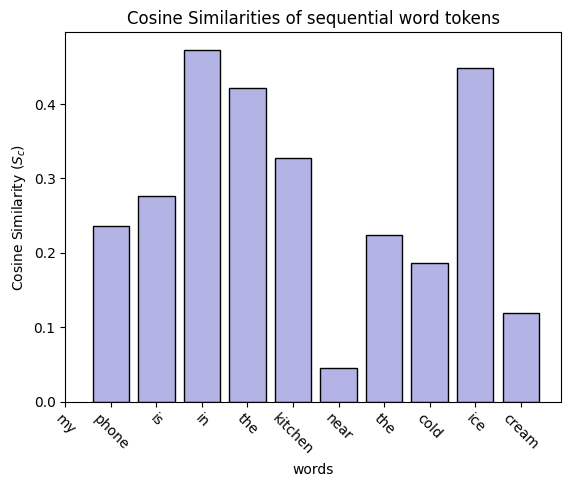

In [128]:
# Visualize
plt.bar(np.arange(len(cs)-1), cs[:-1], facecolor=[.7,.7,.9], edgecolor='k')
plt.gca().set(xlabel='words', ylabel='Cosine Similarity ($S_c$)', title='Cosine Similarities of sequential word tokens')
plt.xticks(np.arange(len(cs)-1), word_tokens, rotation=-45)

plt.show()

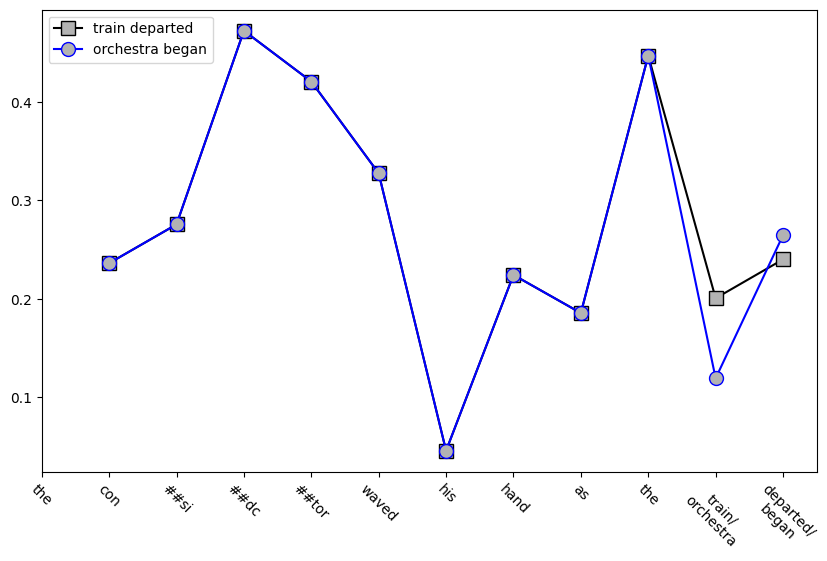

In [103]:
# Cosine similarities of words with changing meaning
fig = plt.figure(figsize=(10,6))

sentences = [
    'The considctor waved his hand as the train departed',
    'The considctor waved his hand as the orchestra began'
]

for i, sent in enumerate(sentences):

  token_ids = tokenizer.encode(sent)[1:-1]

  cossim = np.full(len(token_ids),np.nan)

  for ti in range(1,len(token_ids)):
    cossim[ti] = torch.cosine_similarity(emb[token_ids[ti-1],:], emb[token_ids[ti],:], dim=0).item()

  plt.plot(cossim,['ks-','bo-'][i], markerfacecolor=[.7,.7,.7], markersize=10, label=' '. join(tokenizer.decode(token_ids).split()[-2:]))
  xticklabs = [tokenizer.decode(t) for t in token_ids]
  xticklabs[-2] = f'train/\norchestra'
  xticklabs[-1] = f'departed/\nbegan'
  plt.gca().set(xticks=range(0,len(token_ids)), xticklabels=xticklabs)
  plt.gca().tick_params(axis='x', rotation=-45)

plt.legend()
plt.show()